# Tokenization

## Byte Pair Encoding Tokenizer

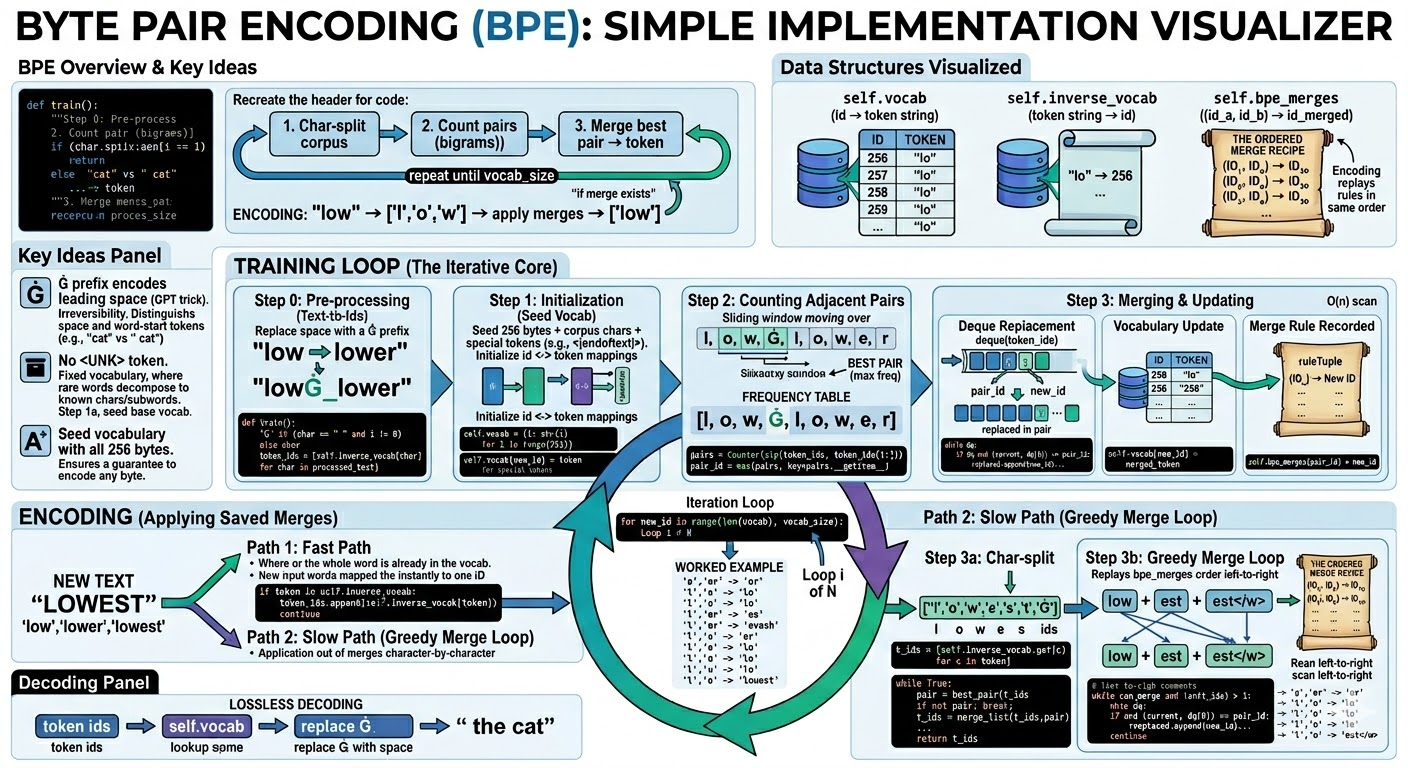

## Core Idea
Iteratively merge the most frequent adjacent token pair in a corpus, building up a vocabulary of subword tokens from raw characters. No `<UNK>` tokens — rare words just decompose into smaller known pieces.

---

## Data Structures

| Attribute | What it stores |
|---|---|
| `vocab` | `id → token string` (e.g. `256 → "lo"`) |
| `inverse_vocab` | `token string → id` (reverse lookup) |
| `bpe_merges` | `(id_a, id_b) → id_merged` — the ordered merge recipe |

---

## Training (`train`)

1. **Pre-process** — replace spaces with `Ġ` prefix on the following character (`"low lower"` → `"lowĠlower"`), making whitespace reversible without a separate list.

2. **Seed vocab** with all 256 bytes (guarantees any input is encodable) + any extra chars in the corpus (including `Ġ`) + special tokens (e.g. `<|endoftext|>`).

3. **Convert corpus** to a flat list of token ids (one id per character at this stage).

4. **Merge loop** — repeat until `vocab_size` is reached:
   - **Count pairs** — `Counter(zip(ids, ids[1:]))` tallies every adjacent pair in one pass.
   - **Find best** — `max(pairs, key=pairs.__getitem__)` picks highest-frequency pair.
   - **Replace** — single left-to-right `deque` scan: whenever `(current, next) == best_pair`, emit `new_id` and skip both originals. O(n).
   - **Record** — `bpe_merges[(id_a, id_b)] = new_id` and update `vocab`/`inverse_vocab` with the concatenated string.

---

## Encoding (`encode`)

Works **word by word** (unlike training which operated on the whole corpus):

1. Split on whitespace; re-attach `Ġ` as prefix to every non-first word.
2. **Fast path** — if the whole word is already a vocab token, emit its id directly.
3. **Slow path** — char-split the word into ids, then **greedily replay merge rules** left-to-right in training order. Loop until no rule fires.

---

## Decoding (`decode`)

Look up each id in `vocab`, replace `Ġ` with a space. Fully lossless.

---

## Key Tricks to Remember
- **`Ġ` prefix** encodes leading spaces *inside* the token — `"cat"` and `" cat"` become distinct tokens.
- **Ordered merges matter** — encoding must replay rules in the exact same order they were learned.
- **`deque` in training** gives O(n) replacement vs O(n²) for naive list splicing.
- **Base 256 seed** is what eliminates `<UNK>` — any byte sequence is always representable.

In [ ]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    BYTE PAIR ENCODING — SIMPLE IMPLEMENTATION                ║
║                                                                              ║
║  See the visual cheat-sheet above for the full picture. Quick recap:         ║
║                                                                              ║
║  TRAINING (run once on corpus)                                               ║
║  ┌──────────────┐     ┌─────────────────┐     ┌──────────────────┐           ║
║  │ 1. Char-split│ --> │ 2. Count pairs  │ --> │ 3. Merge best    │──┐        ║
║  │    corpus    │     │    (bigrams)    │     │    pair → token  │  │        ║
║  └──────────────┘     └─────────────────┘     └──────────────────┘  │        ║
║                              ▲                                      │        ║
║                              └────────── repeat until vocab_size ───┘        ║
║                                                                              ║
║  ENCODING (apply saved merge rules to new text, in order)                    ║
║  "low" → ['l','o','w'] → apply merges → ['low']  (if merge exists)           ║
║                                                                              ║
║  KEY IDEAS                                                                   ║
║  • Ġ prefix  : encodes a leading space (GPT-3/4 trick), so "cat" and         ║
║                " cat" are distinct tokens                                    ║
║  • </w> alt  : some implementations append end-of-word instead               ║
║  • Fixed vocab, no <UNK>: rare words decompose to known subwords/chars       ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

from collections import Counter, deque


class BPETokenizerSimple:
    """
    Minimal BPE tokenizer that mirrors the three-box loop in the visual:
        1. Char-split  →  2. Count pairs  →  3. Merge best  →  repeat
    """

    def __init__(self):
        # ── Vocab ──────────────────────────────────────────────────────────
        # vocab        : id  → token string   (e.g. 256 → "lo")
        # inverse_vocab: token string → id    (reverse lookup for encoding)
        self.vocab = {}
        self.inverse_vocab = {}

        # ── Merge table ────────────────────────────────────────────────────
        # bpe_merges: (id_a, id_b) → id_merged
        # This is the *ordered* merge recipe produced during training.
        # Encoding replays these rules in the same order.
        self.bpe_merges = {}

    # ──────────────────────────────────────────────────────────────────────────
    # TRAINING
    # ──────────────────────────────────────────────────────────────────────────
    def train(self, text, vocab_size, allowed_special={"<|endoftext|>"}):
        """
        Learn BPE merge rules from `text` until the vocabulary reaches
        `vocab_size` tokens.

        Visual walkthrough (see diagram "worked example"):
            "low lower lowest"
            Step 0: l o w ↵  l o w e r ↵  l o w e s t ↵   ← char-level
            Step 1: merge ("e","r") → "er"   (freq 2)
            Step 2: merge ("l","o") → "lo"   (freq 3)
            Step 3: merge ("lo","w") → "low"  (freq 3)
            ...
        """

        # ── Step 0: Pre-process ────────────────────────────────────────────
        # Replace every space (except the very first character) with the
        # Ġ prefix on the *following* character.  This embeds whitespace
        # information directly into the token, so the tokenizer is
        # reversible without a separate space list.
        #
        #   "low lower" → "lowĠlower"
        #
        processed_text = "".join(
            "Ġ" if (char == " " and i != 0) else char
            for i, char in enumerate(text)
        )

        # ── Step 1a: Seed vocabulary with all 256 bytes ────────────────────
        # This guarantees we can always encode *any* byte — no <UNK> token
        # needed.  Characters not in the training text just never get merged.
        unique_chars = [chr(i) for i in range(256)]

        # Also add any chars that appear in the text but fall outside 0-255
        # (e.g. Ġ itself, non-latin unicode in the corpus).
        unique_chars.extend(
            char for char in sorted(set(processed_text))
            if char not in unique_chars
        )
        if "Ġ" not in unique_chars:
            unique_chars.append("Ġ")

        # Build the initial id ↔ token mappings
        self.vocab         = {i: char for i, char in enumerate(unique_chars)}   # id → token
        self.inverse_vocab = {char: i  for i, char in self.vocab.items()}        # token → id

        # ── Step 1b: Add special tokens ────────────────────────────────────
        # Special tokens like <|endoftext|> act as document separators and
        # are never split by BPE — they go straight into the vocab as-is.
        for token in allowed_special:
            if token not in self.inverse_vocab:
                new_id = len(self.vocab)
                self.vocab[new_id]       = token
                self.inverse_vocab[token] = new_id

        # Convert the entire pre-processed text into a flat list of token ids
        # (one id per character at this point)
        token_ids = [self.inverse_vocab[char] for char in processed_text]

        # ── Steps 2 & 3: Iterative merge loop ─────────────────────────────
        # Each iteration of this loop adds one new token to the vocabulary.
        # We run until we hit the requested vocab_size.
        for new_id in range(len(self.vocab), vocab_size):

            # ── Step 2: Count all adjacent pairs ──────────────────────────
            # zip(token_ids, token_ids[1:]) slides a window of size 2 over
            # the sequence, producing every (left, right) neighbour pair.
            # Counter tallies frequencies in one pass.
            #
            #  [l, o, w, Ġ, l, o, w, e, r]
            #   ├──┤ ├──┤ ├──┤ ...
            #  (l,o)(o,w)(w,Ġ) ...   ← pairs
            pairs = Counter(zip(token_ids, token_ids[1:]))
            if not pairs:
                break   # Nothing left to merge (corpus is a single token)

            # ── Step 3a: Find the best pair ───────────────────────────────
            # "Best" = highest frequency.  Ties are broken arbitrarily here;
            # production implementations often use leftmost-tie-breaking.
            pair_id = max(pairs, key=pairs.__getitem__)

            # ── Step 3b: Replace every occurrence of the pair ─────────────
            # We do a single left-to-right scan with a deque for O(n) speed.
            # Whenever we see (current, next) == pair_id, we emit new_id and
            # skip both originals.
            dq = deque(token_ids)
            replaced = []
            while dq:
                current = dq.popleft()
                if dq and (current, dq[0]) == pair_id:
                    replaced.append(new_id)   # ← the merged token
                    dq.popleft()              # skip the right half of the pair
                else:
                    replaced.append(current)
            token_ids = replaced

            # ── Step 3c: Record the merge rule ────────────────────────────
            # bpe_merges stores *how* to reconstruct new_id during encoding:
            # "if you see pair_id, replace with new_id"
            self.bpe_merges[pair_id] = new_id

            # ── Step 3d: Update the vocabulary ────────────────────────────
            merged_token                  = self.vocab[pair_id[0]] + self.vocab[pair_id[1]]
            self.vocab[new_id]            = merged_token
            self.inverse_vocab[merged_token] = new_id
            # e.g. vocab[256] = "lo",  vocab[257] = "low", ...

    # ──────────────────────────────────────────────────────────────────────────
    # ENCODING  (apply saved merge rules to new text)
    # ──────────────────────────────────────────────────────────────────────────
    def encode(self, text):
        """
        Convert a string into a list of token ids using the learned merges.

        Unlike training (which operates on the whole corpus at once),
        encoding works *word by word*:
            1. Attach Ġ prefix to every non-first word
            2. If the whole word is already a known token → done
            3. Otherwise: char-split, then greedily apply merge rules
               in the order they were learned (leftmost-first scan)
        """

        # ── Pre-process: same space→Ġ convention as training ──────────────
        # Split on whitespace, then re-attach Ġ as a *prefix* to each word
        # (except the first word or newlines, which have no leading space).
        words = text.replace("\n", " \n ").split()
        tokens = [
            "Ġ" + word if (i > 0 and not word.startswith("\n")) else word
            for i, word in enumerate(words)
        ]

        token_ids = []
        for token in tokens:

            # Fast path: the whole word (with Ġ) is already in the vocab
            # This happens for common words after enough merges.
            if token in self.inverse_vocab:
                token_ids.append(self.inverse_vocab[token])
                continue

            # Slow path: apply BPE merges character by character
            # ── 3a. Char-split the word into initial ids ──────────────────
            t_ids = [self.inverse_vocab.get(c) for c in token]

            # ── 3b. Greedy merge loop ─────────────────────────────────────
            # Replay merge rules left-to-right until no rule fires.
            # One pass may unlock new pairs, so we loop until stable.
            #
            # Example:  ['l','o','w','e','r']
            #   pass 1: ("l","o") → "lo"    →  ['lo','w','e','r']   (if rule exists)
            #   pass 2: ("lo","w") → "low"  →  ['low','e','r']
            #   pass 3: no rules fire → done
            can_merge = True
            while can_merge and len(t_ids) > 1:
                can_merge = False
                new_tokens, i = [], 0

                while i < len(t_ids) - 1:
                    pair = (t_ids[i], t_ids[i + 1])
                    if pair in self.bpe_merges:
                        # Merge this pair
                        new_tokens.append(self.bpe_merges[pair])
                        i += 2           # skip both consumed tokens
                        can_merge = True  # at least one merge happened → loop again
                    else:
                        new_tokens.append(t_ids[i])
                        i += 1

                if i < len(t_ids):       # flush the last token if not consumed
                    new_tokens.append(t_ids[i])
                t_ids = new_tokens

            token_ids.extend(t_ids)

        return token_ids

    # ──────────────────────────────────────────────────────────────────────────
    # DECODING  (token ids → original string)
    # ──────────────────────────────────────────────────────────────────────────
    def decode(self, token_ids):
        """
        Convert token ids back to a string.
        Simply look each id up in vocab and strip the Ġ prefix → space.

        This is lossless for whitespace *between* words because Ġ carries
        the "preceded by a space" information inside the token itself.
        """
        return "".join(
            self.vocab[tid].replace("Ġ", " ")  # Ġword → " word"
            if self.vocab[tid].startswith("Ġ")
            else self.vocab[tid]
            for tid in token_ids
        )


# ──────────────────────────────────────────────────────────────────────────────
# QUICK SMOKE TEST
# ──────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # ── Train a tiny tokenizer on a small corpus ──────────────────────────
    # With vocab_size=265 we learn 265 - 256 = 9 merge rules on top of
    # the 256 base byte tokens.
    training_text = "the cat in the hat"
    tokenizer = BPETokenizerSimple()
    tokenizer.train(training_text, vocab_size=265)

    # ── Show what got merged ───────────────────────────────────────────────
    print("=== Learned merge rules ===")
    for (id_a, id_b), id_merged in tokenizer.bpe_merges.items():
        print(f"  ({tokenizer.vocab[id_a]!r} + {tokenizer.vocab[id_b]!r})"
              f"  →  {tokenizer.vocab[id_merged]!r}  [id {id_merged}]")

    # ── Encode / decode round-trip ─────────────────────────────────────────
    print("\n=== Round-trip ===")
    test_text = "the cat"
    encoded = tokenizer.encode(test_text)
    decoded = tokenizer.decode(encoded)
    print(f"  input  : {test_text!r}")
    print(f"  encoded: {encoded}")
    print(f"  tokens : {[tokenizer.vocab[i] for i in encoded]}")
    print(f"  decoded: {decoded!r}")
    assert decoded == test_text, "Decode mismatch!"
    print("  ✓ round-trip OK")

=== Learned merge rules ===
  ('t' + 'h')  →  'th'  [id 258]
  ('th' + 'e')  →  'the'  [id 259]
  ('the' + 'Ġ')  →  'theĠ'  [id 260]
  ('a' + 't')  →  'at'  [id 261]
  ('theĠ' + 'c')  →  'theĠc'  [id 262]
  ('theĠc' + 'at')  →  'theĠcat'  [id 263]
  ('theĠcat' + 'Ġ')  →  'theĠcatĠ'  [id 264]

=== Round-trip ===
  input  : 'the cat'
  encoded: [259, 256, 99, 261]
  tokens : ['the', 'Ġ', 'c', 'at']
  decoded: 'the cat'
  ✓ round-trip OK


## Tokens to Embeddings

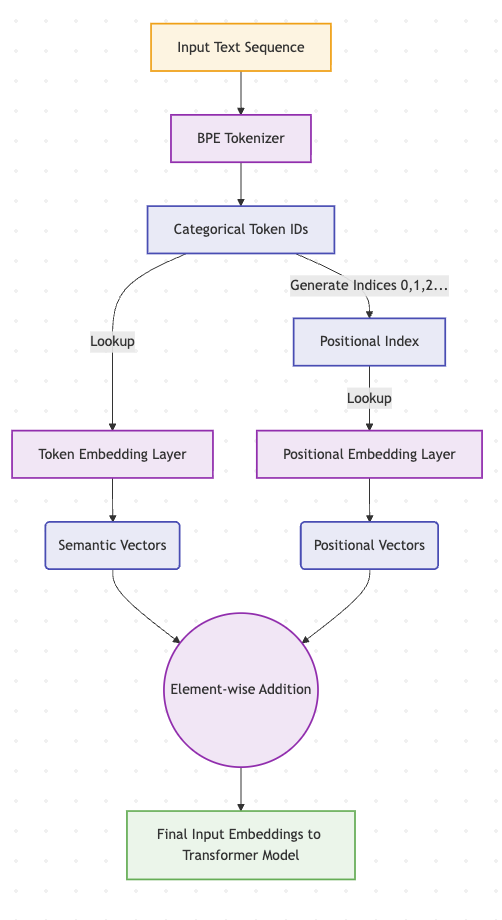

In [ ]:
# --- STEP 2: Token and Positional Embeddings ---
import torch

# Simulate a batch of data: Batch Size = 2, Context Length (Sequence) = 4
# These integers represent tokens derived from our BPE tokenizer
input_ids = torch.tensor([
    [256, 10, 45, 99],
    [10, 256, 12, 10]
])

vocab_size = 50000     # Size of the tokenizer's vocabulary
max_length = 4         # Maximum context size
output_dim = 256       # The embedding dimension size

# 1. Initialize the PyTorch Embedding Layers
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
pos_embedding_layer = torch.nn.Embedding(max_length, output_dim)

# 2. Extract Token Embeddings
# Shape transforms from (Batch, Seq_Len) -> (Batch, Seq_Len, Embed_Dim)
token_embeddings = token_embedding_layer(input_ids)
print(f"Token Embeddings Shape: {token_embeddings.shape}")

# 3. Create and Extract Positional Embeddings
# Create an array of indices: [0, 1, 2, 3]
positions = torch.arange(max_length)
pos_embeddings = pos_embedding_layer(positions)
print(f"Positional Embeddings Shape: {pos_embeddings.shape}")

# 4. Create the final Input Embeddings for the LLM
# PyTorch automatically broadcasts the pos_embeddings across the batch dimension
input_embeddings = token_embeddings + pos_embeddings
print(f"Final LLM Input Shape: {input_embeddings.shape}")

Token Embeddings Shape: torch.Size([2, 4, 256])
Positional Embeddings Shape: torch.Size([4, 256])
Final LLM Input Shape: torch.Size([2, 4, 256])
